<a href="https://colab.research.google.com/github/SammyBoi242006/CCPS_project/blob/main/notebooks/data_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install albumentations timm -q
print("Installed libraries")

Installed libraries


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.11.0+cu128
GPU available: True
Device: Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Paths
PLANTVILLAGE = '/content/drive/MyDrive/project/data/plantvillage_tomato/PlantVillage'
RESULTS = '/content/drive/MyDrive/project/results'
os.makedirs(RESULTS, exist_ok=True)

# Config — single place to change settings
CONFIG = {
    'image_size': 224,
    'batch_size': 32,
    'num_workers': 2,
    'train_split': 0.7,
    'val_split': 0.15,
    'test_split': 0.15,
    'seed': 42,
    # ImageNet normalization for CAFormer pretrained weights
    'mean': [0.485, 0.456, 0.406],
    'std':  [0.229, 0.224, 0.225],
}

print("Config ready:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Mounted at /content/drive
Config ready:
  image_size: 224
  batch_size: 32
  num_workers: 2
  train_split: 0.7
  val_split: 0.15
  test_split: 0.15
  seed: 42
  mean: [0.485, 0.456, 0.406]
  std: [0.229, 0.224, 0.225]


In [4]:
import random
random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])

# Only Tomato classes
TOMATO_CLASSES = sorted([
    cls for cls in os.listdir(PLANTVILLAGE)
    if cls.startswith('Tomato') and os.path.isdir(os.path.join(PLANTVILLAGE, cls))
])

class_to_idx = {cls: idx for idx, cls in enumerate(TOMATO_CLASSES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print("Classes found:")
for cls, idx in class_to_idx.items():
    print(f"  {idx}: {cls}")

# Build full list of (image_path, label)
all_samples = []
for cls in TOMATO_CLASSES:
    cls_path = os.path.join(PLANTVILLAGE, cls)
    for img_file in os.listdir(cls_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_samples.append((os.path.join(cls_path, img_file), class_to_idx[cls]))

print(f"\nTotal samples loaded: {len(all_samples)}")

Classes found:
  0: Tomato_Bacterial_spot
  1: Tomato_Early_blight
  2: Tomato_Late_blight
  3: Tomato_Leaf_Mold
  4: Tomato_Septoria_leaf_spot
  5: Tomato_Spider_mites_Two_spotted_spider_mite
  6: Tomato__Target_Spot
  7: Tomato__Tomato_YellowLeaf__Curl_Virus
  8: Tomato__Tomato_mosaic_virus
  9: Tomato_healthy

Total samples loaded: 16011


In [6]:
from sklearn.model_selection import train_test_split

# Separate paths and labels
paths = [s[0] for s in all_samples]
labels = [s[1] for s in all_samples]

# First split: train vs (val + test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels,
    test_size=(CONFIG['val_split'] + CONFIG['test_split']),
    stratify=labels,  # maintains class balance in each split
    random_state=CONFIG['seed']
)

# Second split: val vs test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=CONFIG['test_split'] / (CONFIG['val_split'] + CONFIG['test_split']),
    stratify=temp_labels,
    random_state=CONFIG['seed']
)

print(f"Train samples : {len(train_paths)}")
print(f"Val samples   : {len(val_paths)}")
print(f"Test samples  : {len(test_paths)}")
print(f"Total         : {len(train_paths) + len(val_paths) + len(test_paths)}")

Train samples : 11207
Val samples   : 2402
Test samples  : 2402
Total         : 16011


In [7]:
# TRAINING augmentation — full pipeline from your doc
train_transform = A.Compose([
    # Category 1 — Preprocessing
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),

    # Category 2 — Standard Augmentation
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.5),
    A.RandomResizedCrop(
        size=(CONFIG['image_size'], CONFIG['image_size']),
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1),
        p=0.5
    ),
    A.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.1,
        p=0.5
    ),

    # Category 3 — Disease-Aware Augmentation (Your novelty)
    A.RandomShadow(p=0.3),
    A.CoarseDropout(
        max_holes=8,
        max_height=20,
        max_width=20,
        p=0.3
    ),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.GaussianBlur(blur_limit=3, p=0.2),

    # Category 1 — Normalization (always last before tensor)
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

# VALIDATION and TEST — preprocessing only, no augmentation
val_test_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

print("Augmentation pipelines ready.")

Augmentation pipelines ready.


/tmp/ipykernel_3283/2746002065.py:26: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(
/tmp/ipykernel_3283/2746002065.py:32: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


In [8]:
class TomatoDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.paths[idx]).convert('RGB'))
        label = self.labels[idx]

        if self.transform:
            img = self.transform(image=img)['image']

        return img, label

# Create datasets
train_dataset = TomatoDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = TomatoDataset(val_paths,   val_labels,   transform=val_test_transform)
test_dataset  = TomatoDataset(test_paths,  test_labels,  transform=val_test_transform)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset  : {len(val_dataset)}")
print(f"Test dataset : {len(test_dataset)}")

Train dataset: 11207
Val dataset  : 2402
Test dataset : 2402


In [9]:
# Count class frequencies in training set
class_counts = Counter(train_labels)
print("Training class distribution:")
for idx, count in sorted(class_counts.items()):
    print(f"  {idx_to_class[idx]}: {count}")

# Compute weight per sample
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]
sample_weights = torch.tensor(sample_weights, dtype=torch.float)

# Weighted sampler — minority classes sampled more often
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("\nClass weights (higher = sampled more):")
for idx, weight in sorted(class_weights.items()):
    print(f"  {idx_to_class[idx]}: {weight:.6f}")

Training class distribution:
  Tomato_Bacterial_spot: 1489
  Tomato_Early_blight: 700
  Tomato_Late_blight: 1336
  Tomato_Leaf_Mold: 666
  Tomato_Septoria_leaf_spot: 1240
  Tomato_Spider_mites_Two_spotted_spider_mite: 1173
  Tomato__Target_Spot: 983
  Tomato__Tomato_YellowLeaf__Curl_Virus: 2245
  Tomato__Tomato_mosaic_virus: 261
  Tomato_healthy: 1114

Class weights (higher = sampled more):
  Tomato_Bacterial_spot: 0.000672
  Tomato_Early_blight: 0.001429
  Tomato_Late_blight: 0.000749
  Tomato_Leaf_Mold: 0.001502
  Tomato_Septoria_leaf_spot: 0.000806
  Tomato_Spider_mites_Two_spotted_spider_mite: 0.000853
  Tomato__Target_Spot: 0.001017
  Tomato__Tomato_YellowLeaf__Curl_Virus: 0.000445
  Tomato__Tomato_mosaic_virus: 0.003831
  Tomato_healthy: 0.000898


In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    sampler=sampler,        # weighted sampler handles shuffling
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 351
Val batches   : 76
Test batches  : 76


In [11]:
# Grab one batch and verify shapes
images, labels = next(iter(train_loader))

print(f"Batch image shape : {images.shape}")   # should be [32, 3, 224, 224]
print(f"Batch label shape : {labels.shape}")   # should be [32]
print(f"Image dtype       : {images.dtype}")   # should be float32
print(f"Label range       : {labels.min()} to {labels.max()}")
print(f"Pixel value range : {images.min():.3f} to {images.max():.3f}")

Batch image shape : torch.Size([32, 3, 224, 224])
Batch label shape : torch.Size([32])
Image dtype       : torch.float32
Label range       : 0 to 9
Pixel value range : -2.118 to 2.640


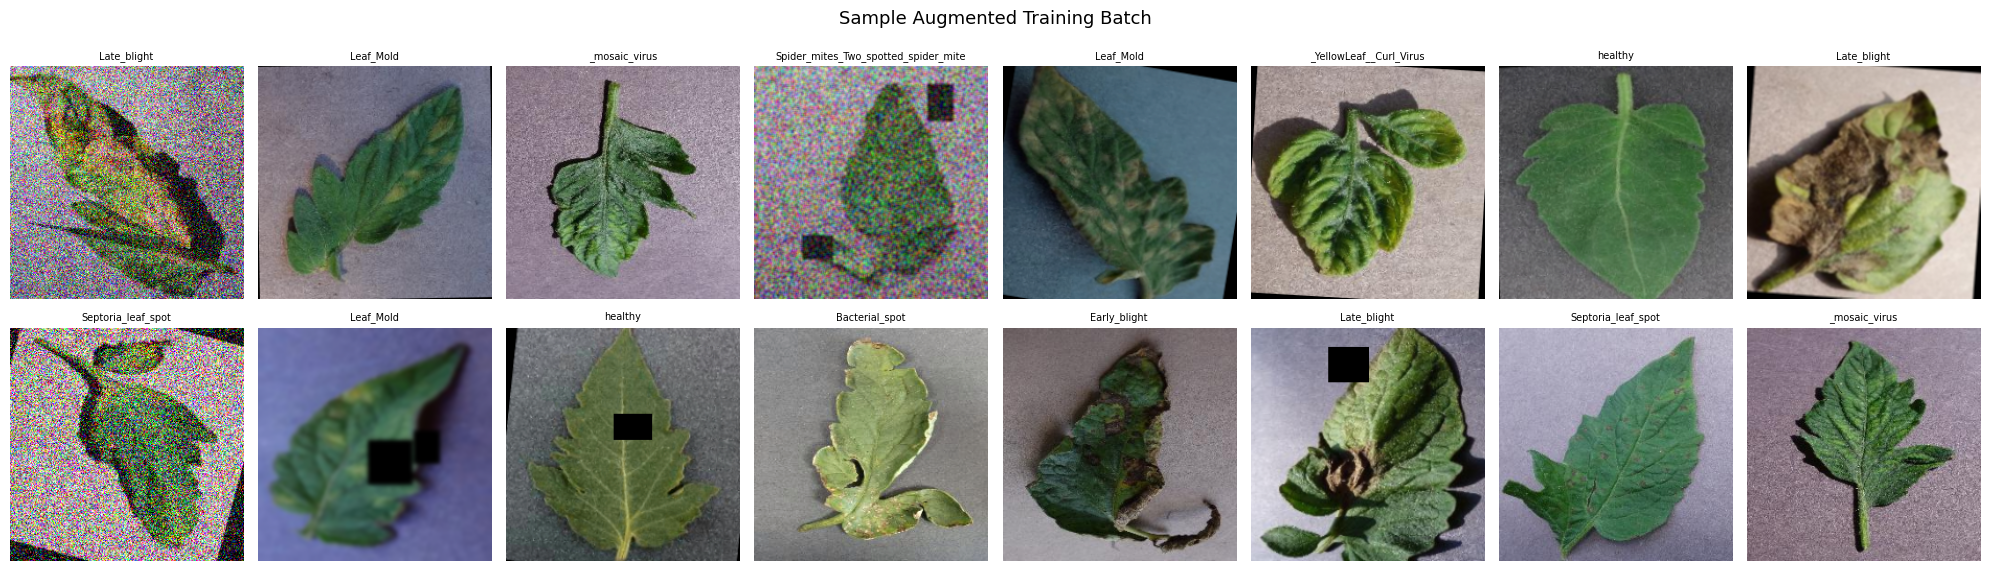

Saved to Drive!


In [12]:
# Unnormalize for display
mean = torch.tensor(CONFIG['mean']).view(3,1,1)
std  = torch.tensor(CONFIG['std']).view(3,1,1)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
axes = axes.flatten()

for i in range(16):
    img = images[i] * std + mean          # unnormalize
    img = img.permute(1, 2, 0).numpy()    # CHW → HWC
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(idx_to_class[labels[i].item()].replace('Tomato_',''), fontsize=7)
    axes[i].axis('off')

plt.suptitle('Sample Augmented Training Batch', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'augmented_samples.png'), dpi=150)
plt.show()